# Week 04: ML and DL for text data

## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

More accurate objective of the course: learning how to use text as data for research objectives, while also trying to understand how to build an LLM from scratch.

What have we done so far:

1.   Introduction to tools to manage text in Python
2.   Preprocessing of text
3.   Tokenization of text (encoder-decoder algorithms)
4.   First try at mathematically representing text (more on this this week)

Now, we are learning practical things that we can do with these representations:

*   similarities, unsupervised (last week)
*   supervised learning (today)

This has a practical use of its own, and will also help us understand the core tools for building LLMs (the model, the metrics to evaluate, the regularization techniques, etc.)

In [3]:
# set random seed
import numpy as np
import warnings
warnings.simplefilter("ignore", DeprecationWarning)
import warnings; warnings.simplefilter('ignore')
%matplotlib inline
import pandas as pd
import re
import matplotlib.pyplot as plt
from string import punctuation

!pip install gensim

import spacy
nlp = spacy.load('en_core_web_sm')

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stoplist = set(stopwords.words('english'))
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import sent_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving sc_cases_cleaned.pkl to sc_cases_cleaned.pkl


In [4]:
df = pd.read_pickle('sc_cases_cleaned.pkl',
                    compression = 'gzip')

df = df.reset_index(drop = True)
df = df.assign(authorship_id=(df['authorship']).astype('category').cat.codes) # Authorship as categorical
df['index'] = df['authorship'] + df['date_standard'].astype(str)
df.rename(columns = {'x_republican':'republican'}, inplace = True)

# Basic preprocessing for the dataset
translator = str.maketrans(' ', ' ', punctuation)
from nltk.tokenize import word_tokenize

def preprocess(doc):
  doc = doc.replace('\r', ' ').replace('\n', ' ')
  doc = re.sub(r"(\d)([A-Za-z])", r"\1 \2", doc) # separate numbers from strings
  doc = re.sub(r"([A-Za-z])(\d)", r"\1 \2", doc) # separate strings from numbers
  d = doc.translate(translator).lower() # remove punctuation
  words = word_tokenize(d)
  words = [w for w in words if w not in stoplist] # remove stopwords
  words = [w if not w.isdigit() else '#' for w in words] # normalize numbers
  output = ' '.join(words) # Let's not tokenize now
  return output

### ML Basics: Pipeline

Feature generation with text data. Let's use the tools we learned last week to generate some features that might help us infer the political affiliation of each judge.

(For didactic purposes we only keep the TOP 50 terms with highest overall TF-IDF scores).

In [5]:
preprocessed_opinion = list(map(preprocess, df['opinion_text'])) # Note list()

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=0.01,
                        max_df=0.9,
                        max_features=50)

X = tfidf.fit_transform(preprocessed_opinion)
words = tfidf.get_feature_names_out()
X_tfidf = pd.DataFrame(X.toarray(), columns=words, index=df['index'])

X = X.todense()

for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = column
df

,case_name,opinion_type,date_standard,authorship,republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,...,x_statute,x_statutory,x_supra,x_time,x_trial,x_upon,x_usc,x_use,x_within,x_without
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...,...,0.038843,0.021469,0.035132,0.339052,0.025726,0.036305,0.123286,0.000000,0.018224,0.017635
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...,...,0.138945,0.000000,0.031418,0.000000,0.000000,0.000000,0.094501,0.000000,0.032595,0.031542
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...,...,0.115281,0.015929,0.039101,0.052961,0.000000,0.026937,0.078407,0.000000,0.067609,0.052340
3,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...,...,0.013644,0.045248,0.148092,0.062684,0.000000,0.051011,0.136107,0.042386,0.422510,0.049558
4,"REGINALD A. WILKINSON, DIRECTOR, OHIO DEPARTME...",majority,2005-06-13,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],4.0,4230.0,Justice Kennedy delivered the opinion of the C...,...,0.000000,0.000000,0.104754,0.119718,0.038354,0.081188,0.039386,0.029982,0.095094,0.039438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,"MICHAEL F. EASLEY, * GOVERNOR OF NORTH CAROLIN...",majority,2001-04-18,BREYER,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'REHNQUIST, WILLIAM', 'SC...",2.0,1236.0,JUSTICE BREYER delivered the opinion of the Co...,...,0.000000,0.000000,0.068422,0.050551,0.054658,0.115700,0.006237,0.007121,0.070986,0.043713
764,"GAIL ATWATER, et al. v. CITY OF LAGO VISTA et al.",majority,2001-04-24,SOUTER,1.0,"['KENNEDY, ANTHONY', 'REHNQUIST, WILLIAM', 'SC...","['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...",1.0,3120.0,JUSTICE SOUTER delivered the opinion of the Co...,...,0.222988,0.049299,0.121012,0.081954,0.023630,0.083367,0.056620,0.046180,0.050218,0.404961
765,"JAMES ALEXANDER, DIRECTOR, ALABAMA DEPARTMENT ...",majority,2001-04-24,SCALIA,1.0,"['KENNEDY, ANTHONY', ""O'CONNOR, SANDRA"", 'REHN...","['BREYER, STEPHEN', 'GINSBURG, RUTH', 'SOUTER,...",9.0,4986.0,JUSTICE SCALIA delivered the opinion of the Co...,...,0.249824,0.105203,0.129119,0.010931,0.000000,0.022238,0.151034,0.000000,0.011163,0.032407
766,UNITED STATES v. OAKLAND CANNABIS BUYERS' COOP...,majority,2001-05-14,THOMAS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,736.0,JUSTICE THOMAS delivered the opinion of the Co...,...,0.395127,0.097062,0.092654,0.000000,0.000000,0.027356,0.106169,0.242457,0.000000,0.053154


In [6]:
# Keep only predictors and y
features = ['x_'+ x for x in words]
dfp = df[features]

### FEATURE SCALING: Standardize all features to same scale
Why? Neural networks and gradient-based algorithms perform better when:

- Features are on similar scales (prevents dominance by large-value features)
- Data is centered around 0 (helps with gradient flow)

In [7]:
from sklearn.preprocessing import StandardScaler  # Import standardization tool

scaler = StandardScaler(with_mean=False)  # Initialize scaler object (sparse)
X = scaler.fit_transform(dfp)  # Two-step process in one:
                               # 1. fit(): Calculate mean and std for each column
                               # 2. transform(): Apply z-score normalization: (x - μ) / σ

# Convert scaled numpy array back to pandas DataFrame
dfp = pd.DataFrame(X, columns=dfp.columns)

### Categorical to One-Hot Encoder

In the interest of time, let's assume the variable 'topic_id' came from a topic model fit on the text.

Problem: Machine learning models require numeric input, but 'topic_id' is categorical.

Solution: Create binary "dummy" variables - one column per unique category

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)  # sparse_output=False returns dense array (easier for DataFrame)

topic = df['topic_id']

# OneHotEncoder requires 2D input, so reshape from (n,) to (n, 1)
print(f"Original shape: {topic.values.shape}")  # (n,)
print(f"Reshaped: {topic.values.reshape(-1, 1).shape}")  # (n, 1)

topic_fes = encoder.fit_transform(topic.values.reshape(-1, 1)) # Fit encoder and transform to one-hot representation

# Create meaningful column names: j_0, j_1, j_2, etc.
# Each column represents one unique judge
topic_ids = [f't_{x}' for x in range(len(topic.unique()))]
topic_fes = pd.DataFrame(topic_fes, columns=topic_ids)
dfp = pd.concat([dfp, topic_fes], axis=1)

Original shape: (768,)
Reshaped: (768, 1)


In the interest of time, these are the only regressors we will use. However, we can build more using the tools we have seen:

1) Build linguistic features using spacy (see notebook posted after)
2) If dimensionality is an issue, one can instead use principal components
3) Style features
4) n-grams

Now we split the dataset into training (80%) and test (20%) sets. This is crucial for evaluating model performance on unseen data

In [9]:
dfp = pd.concat([dfp, df[['republican']]], axis=1)

# Generate split
from sklearn.model_selection import train_test_split #NEW

train, test = train_test_split(dfp,
                               test_size=0.2,  # Reserve 20% of data for final evaluation
                               random_state=202,  # Set seed so split is reproducible across runs
                               shuffle=True)  # Randomly shuffle to break any temporal patterns
                                             # Important: prevents model from learning time-dependent artifacts (confounders)

# Define y = f(x)

features = ['x_'+ x for x in words] + topic_ids

# Training dataset
Xtrain = train[features]
Ytrain = train['republican']

# Test dataset:
Xtest = test[features]
Ytest = test['republican']

Now we can fit some models to the training data set and evaluate their performance using the metrics seen in class. Let's see our outcome variable to decide which metrics to use:

In [8]:
dfp['republican'].value_counts()

republican
1.0    594
0.0    174
Name: count, dtype: int64

The classes seem unbalanced, so we might benefit from using the F1 Score: Harmonic mean of precision and recall

Where precision is, of predicted positives, how many are correct? And recall is of actual positives, how many did we find?


In [10]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC  # Support Vector Machine
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report)

models = {
    'Random Forest': RandomForestClassifier(),
    'Elastic Net': LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga'),
    'Bagging': BaggingClassifier(),
    'SVM': SVC()
}


Train and calculate test F1 Socres to decide which is the best model:

In [13]:
test_results = {}

for name, model in models.items():
    # Fit on training set
    model.fit(Xtrain, Ytrain)

    # Predict on test set
    Ypred = model.predict(Xtest)

    # Calculate F1-score
    f1 = f1_score(Ytest, Ypred)
    test_results[name] = f1

    print(f"{name:15s}: {f1:.4f}")

Random Forest  : 0.8824
Elastic Net    : 0.8889
Bagging        : 0.8880
SVM            : 0.8922


In [14]:
best_model_name = max(test_results.items(), key=lambda x: x[1])[0]
print("\n" + "=" * 60)
print(f"✓ BEST MODEL: {best_model_name}")
print(f"  Test F1-score: {test_results[best_model_name]:.4f}")
print("=" * 60)


✓ BEST MODEL: SVM
  Test F1-score: 0.8922


We can do more than this to improve. For example, we can use cross validation and grid search to select the best hyper parameters. Let's first do it for XGBoost.

In [11]:
from xgboost import XGBClassifier #NEW
from sklearn.model_selection import GridSearchCV #NEW
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                            roc_curve, precision_recall_curve, confusion_matrix,
                            ConfusionMatrixDisplay)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],              # Number of boosting rounds
    'max_depth': [3, 5, 10],                  # Maximum tree depth
    'learning_rate': [0.01, 0.3]          # Step size shrinkage (eta)

}

# Initialize XGBoost classifier
xgb = XGBClassifier(
    random_state=202,
    eval_metric='logloss',  # Suppress warning
    use_label_encoder=False  # Suppress warning
)

# Grid Search with 5-fold CV, optimizing for F1-score
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1',            # Optimize for F1 (good for imbalanced data)
    n_jobs=-1,               # Use all CPU cores
    verbose=1                # Show progress
)

# Fit grid search
print("\nFitting grid search (this may take a few minutes)...")
grid_search.fit(Xtrain, Ytrain)

# Print best parameters and score
print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"{param:20s}: {value}")


Fitting grid search (this may take a few minutes)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

BEST HYPERPARAMETERS
learning_rate       : 0.3
max_depth           : 3
n_estimators        : 100


With these hyper-parameters we fit the model on our training data and evaluate final performance on test.

In [12]:
# Get best model
best_xgb = grid_search.best_estimator_

# Predict on test set
Ypred = best_xgb.predict(Xtest)
Ypred_proba = best_xgb.predict_proba(Xtest)[:, 1]  # Probability of positive class

# Calculate metrics
f1 = f1_score(Ytest, Ypred)
roc_auc = roc_auc_score(Ytest, Ypred_proba)
pr_auc = average_precision_score(Ytest, Ypred_proba)  # PR AUC

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(f"F1-score:     {f1:.4f}")
print(f"ROC-AUC:      {roc_auc:.4f}")
print(f"PR-AUC:       {pr_auc:.4f}")


TEST SET PERFORMANCE
F1-score:     0.8880
ROC-AUC:      0.8132
PR-AUC:       0.9412


Here I provide code for other evaluation metrics seen in class, for you to use as you go.

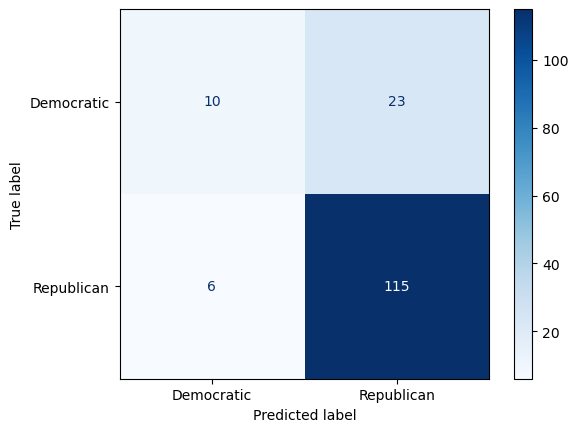

In [13]:
# --- Confusion Matrix ---
cm = confusion_matrix(Ytest, Ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Democratic', 'Republican'])
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

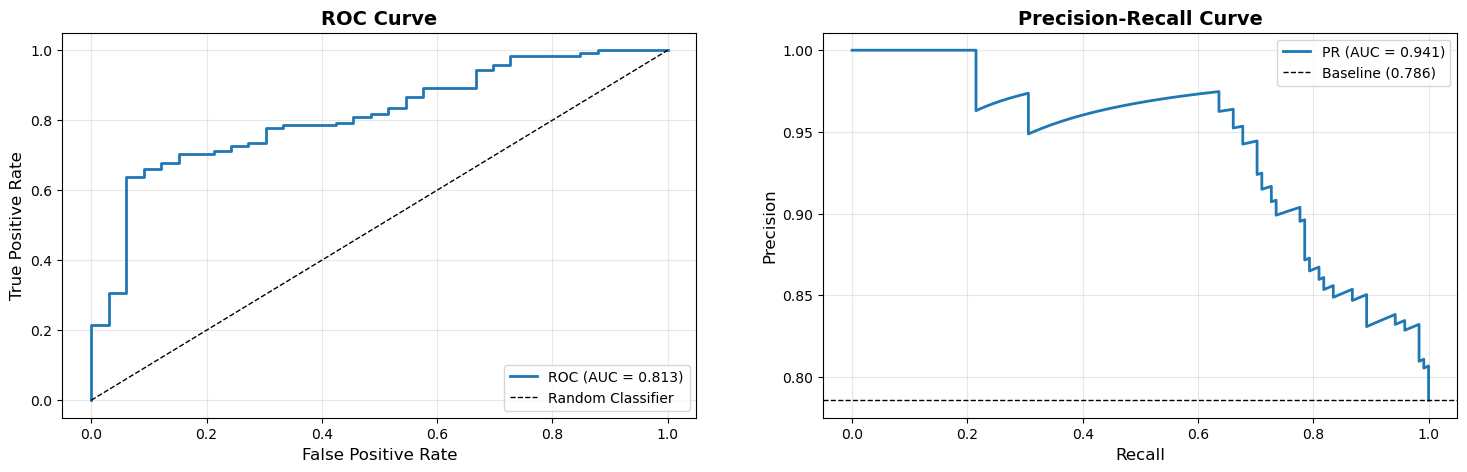

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(Ytest, Ypred_proba)
axes[0].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)


# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(Ytest, Ypred_proba)
axes[1].plot(recall, precision, linewidth=2, label=f'PR (AUC = {pr_auc:.3f})')
# Baseline: proportion of positive class
baseline = Ytest.sum() / len(Ytest)
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1,
                label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)


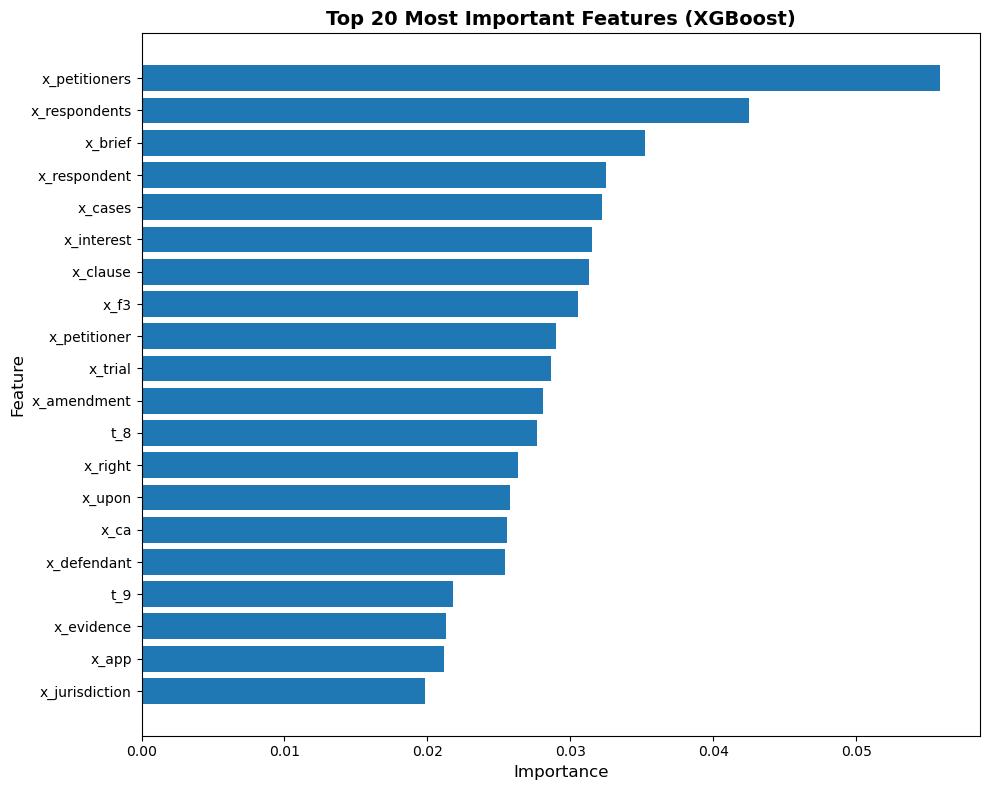

In [15]:
feature_importance = best_xgb.feature_importances_
feature_names = Xtrain.columns

# Create dataframe and sort
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['importance'])
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Deep Learning Essentials: PyTorch

Let's complicate the prediction problem: let's try to predict the log number of cites an opinion gets based on the text.

In [16]:
dfp = pd.concat([dfp, df['log_cite_count']], axis = 1)

train, test = train_test_split(dfp,
                               test_size=0.2,
                               random_state=202,
                               shuffle=True)

features = [col for col in dfp.columns
            if col != 'log_cite_count'
            and col != 'republican']

# Training dataset
Xtrain = train[features]
Ytrain = train['log_cite_count']

# Test dataset
Xtest = test[features]
Ytest = test['log_cite_count']

print(f"Training samples: {len(Xtrain)}")
print(f"Test samples: {len(Xtest)}")
print(f"Number of features: {len(features)}")

Training samples: 614
Test samples: 154
Number of features: 63


In [17]:
import torch #NEW
import torch.nn as nn #NEW
import torch.optim as optim #NEW
from torch.utils.data import Dataset, DataLoader #NEW
import numpy as np #NEW
from sklearn.metrics import accuracy_score, f1_score #NEW
import matplotlib.pyplot as plt #NEW

print("=" * 60)
print("PART 1: SIMPLE PERCEPTRON (with ReLU)")
print("=" * 60)

# Set random seed for reproducibility
torch.manual_seed(202)
np.random.seed(202)

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(Xtrain.values)
Y_train_tensor = torch.LongTensor(Ytrain.values)
X_test_tensor = torch.FloatTensor(Xtest.values)
Y_test_tensor = torch.LongTensor(Ytest.values)

print(f"\nInput shape: {X_train_tensor.shape}")
print(f"Number of classes: {len(Ytrain.unique())}")

PART 1: SIMPLE PERCEPTRON (with ReLU)

Input shape: torch.Size([614, 63])
Number of classes: 566


In [18]:
class SimplePerceptron(nn.Module):
    def __init__(self, input_size):
        super(SimplePerceptron, self).__init__()

        # Linear transformation: z = Wx + b
        self.linear = nn.Linear(input_size, 1)

        # ReLU activation: max(0, x)
        # Ensures output is non-negative
        self.relu = nn.ReLU()

    def forward(self, x):
        # Get linear output
        z = self.linear(x)

        # Apply ReLU: output now in [0, ∞)
        output = self.relu(z)

        return output

In [19]:
# Initialize model
input_size = X_train_tensor.shape[1]
simple_model = SimplePerceptron(input_size)

print(f"\nModel Architecture:")
print(simple_model)
print(f"\nTotal parameters: {sum(p.numel() for p in simple_model.parameters())}")



Model Architecture:
SimplePerceptron(
  (linear): Linear(in_features=63, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 64


Training set up:

Decide on several things, who could be considered hyper-parameters.

1) Loss function
2) Optimizer and learning rate
3) Number of epochs and batch sizes


In [20]:
# Convert to tensors (no normalization needed with ReLU!)
Y_train_tensor = torch.FloatTensor(Ytrain.values).unsqueeze(1)
Y_test_tensor = torch.FloatTensor(Ytest.values).unsqueeze(1)

print(f"\nTarget variable range: [{Ytrain.min():.2f}, {Ytrain.max():.2f}]")

# Loss function: MSELoss
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(simple_model.parameters(), lr=0.001)

# Training parameters
num_epochs = 50
batch_size = 64

# Create DataLoader
class TextDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Create DataLoader
train_dataset = TextDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


Target variable range: [2.40, 13.16]


Finally we train it using a loop. For each epoch, we sample 64 observations each time

In [21]:
train_losses = []

for epoch in range(num_epochs):
    simple_model.train()

    epoch_loss = 0

    for batch_X, batch_Y in train_loader:
        # Forward pass
        predictions = simple_model(batch_X)

        # Compute loss (MSE)
        loss = criterion(predictions, batch_Y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track loss
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss (MSE): {avg_loss:.4f}")


Epoch [10/50], Loss (MSE): 16.9723
Epoch [20/50], Loss (MSE): 5.8176
Epoch [30/50], Loss (MSE): 3.9214
Epoch [40/50], Loss (MSE): 3.4547
Epoch [50/50], Loss (MSE): 3.2041


Model evaluation:

In [22]:
simple_model.eval()

with torch.no_grad():
    predictions = simple_model(X_test_tensor)
    Y_pred_simple = predictions.squeeze().numpy()
    Y_test_np = Y_test_tensor.squeeze().numpy()

# Calculate regression metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_simple = mean_squared_error(Y_test_np, Y_pred_simple)

print("\n" + "=" * 60)
print("SIMPLE PERCEPTRON (ReLU) - TEST SET PERFORMANCE")
print("=" * 60)
print(f"Mean Squared Error (MSE):       {mse_simple:.4f}")


SIMPLE PERCEPTRON (ReLU) - TEST SET PERFORMANCE
Mean Squared Error (MSE):       3.0727


This is basically the same as the multinomial logit. However, the beauty of Deep Learning is when the model is actually deep (a lot of weights, several hidden layers).

Let's build a model with these characteristics.

In [23]:
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_sizes=[512, 256, 128], dropout_rate=0.3):
        super(DeepNN, self).__init__()

        # Layer 1: Input -> Hidden1
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.relu1 = nn.ReLU()  # ReLU: max(0, x)
        self.dropout1 = nn.Dropout(dropout_rate)  # Randomly zero out neurons (prevents overfitting)

        # Layer 2: Hidden1 -> Hidden2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        # Layer 3: Hidden2 -> Hidden3
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_rate)

        # Output layer: Hidden3 -> Single continuous output
        self.fc4 = nn.Linear(hidden_sizes[2], 1)  # Output size = 1 for regression

        # Output activation: ReLU to ensure non-negative predictions
        self.output_relu = nn.ReLU()

    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        # Layer 2
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        # Layer 3
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.dropout3(x)

        # Output layer
        x = self.fc4(x)

        # Apply ReLU to ensure non-negative output
        output = self.output_relu(x)

        return output

# Initialize deep model
input_size = X_train_tensor.shape[1]
deep_model = DeepNN(input_size, hidden_sizes=[512, 256, 128], dropout_rate=0.3)

print(f"\nModel Architecture:")
print(deep_model)
print(f"\nTotal parameters: {sum(p.numel() for p in deep_model.parameters())}")

# Loss function: MSELoss (Mean Squared Error)
# Perfect for regression tasks
criterion = nn.MSELoss()

# Optimizer: Adam with learning rate
optimizer = optim.Adam(deep_model.parameters(), lr=0.001)

# Training parameters
num_epochs = 50
batch_size = 64


Model Architecture:
DeepNN(
  (fc1): Linear(in_features=63, out_features=512, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (output_relu): ReLU()
)

Total parameters: 197121


In [24]:
train_losses_deep = []
test_losses_deep = []

for epoch in range(num_epochs):
    # =========================================================================
    # TRAINING PHASE
    # =========================================================================
    deep_model.train()  # Enable dropout

    train_epoch_loss = 0

    for batch_X, batch_Y in train_loader:
        # Forward pass
        predictions = deep_model(batch_X)

        # Compute loss (MSE)
        loss = criterion(predictions, batch_Y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track loss
        train_epoch_loss += loss.item()

    # Average training loss for this epoch
    avg_train_loss = train_epoch_loss / len(train_loader)
    train_losses_deep.append(avg_train_loss)

    # Test
    deep_model.eval()  # Disable dropout

    with torch.no_grad():
        # Get predictions on full test set
        test_predictions = deep_model(X_test_tensor)

        # Compute test loss
        test_loss = criterion(test_predictions, Y_test_tensor)
        test_losses_deep.append(test_loss.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Test Loss: {test_loss.item():.4f}")

Epoch [10/50], Train Loss: 2.4978, Test Loss: 2.4963
Epoch [20/50], Train Loss: 1.7897, Test Loss: 2.5621
Epoch [30/50], Train Loss: 1.3307, Test Loss: 2.9469
Epoch [40/50], Train Loss: 1.1887, Test Loss: 2.9526
Epoch [50/50], Train Loss: 1.2034, Test Loss: 3.1181


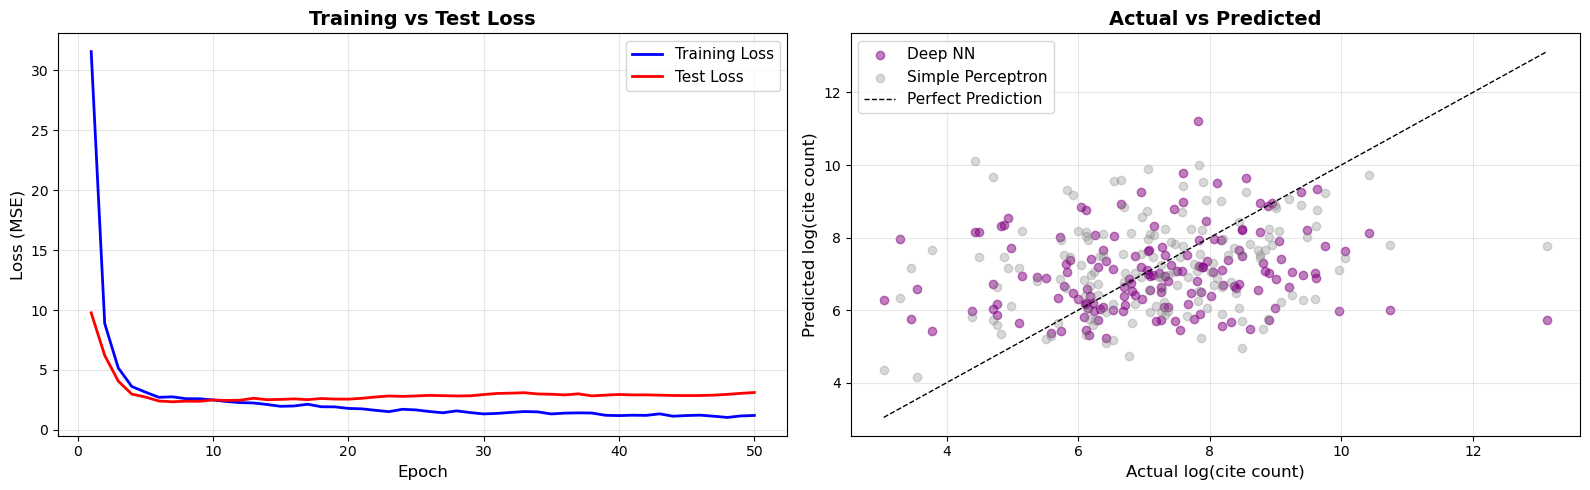

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Train vs Test Loss
epochs_range = range(1, num_epochs + 1)

axes[0].plot(epochs_range, train_losses_deep, label='Training Loss', linewidth=2, color='blue')
axes[0].plot(epochs_range, test_losses_deep, label='Test Loss', linewidth=2, color='red')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training vs Test Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Actual vs Predicted
Y_pred_deep = deep_model(X_test_tensor).detach().squeeze().numpy()
axes[1].scatter(Y_test_np, Y_pred_deep, alpha=0.5, color='purple', label='Deep NN')
axes[1].scatter(Y_test_np, Y_pred_simple, alpha=0.3, color='gray', label='Simple Perceptron')
axes[1].plot([Y_test_np.min(), Y_test_np.max()],
             [Y_test_np.min(), Y_test_np.max()],
             'k--', linewidth=1, label='Perfect Prediction')
axes[1].set_xlabel('Actual log(cite count)', fontsize=12)
axes[1].set_ylabel('Predicted log(cite count)', fontsize=12)
axes[1].set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()



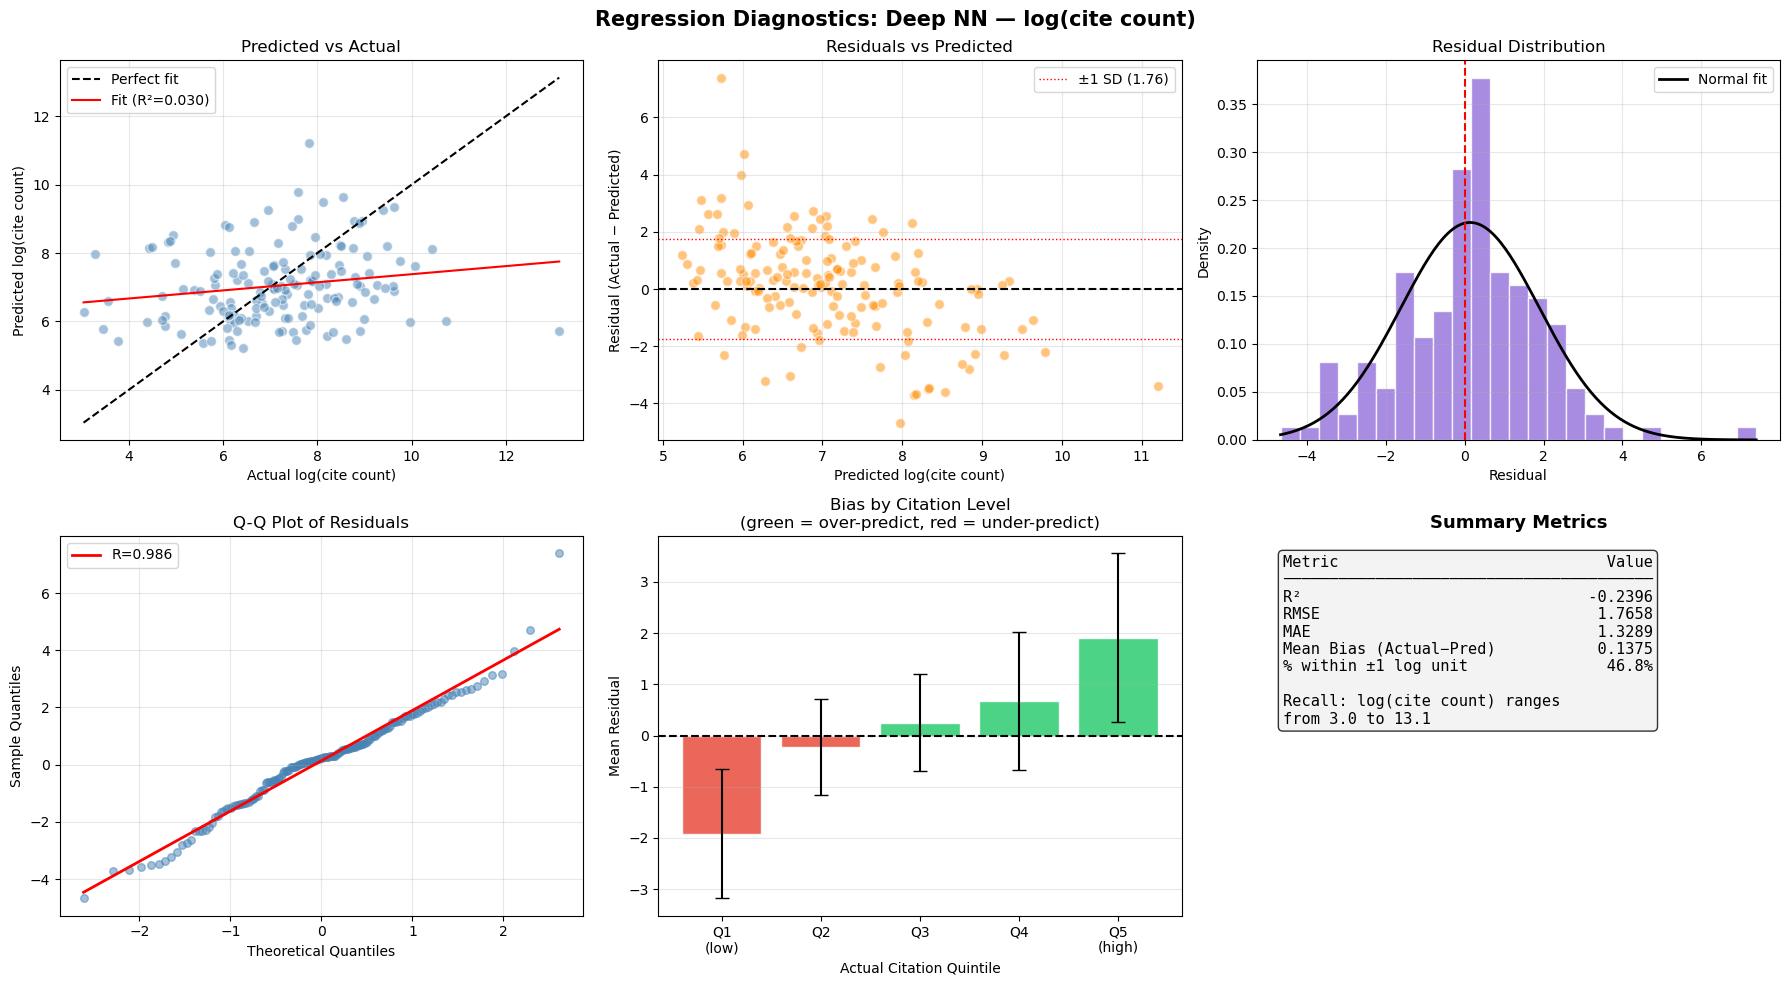

In [29]:

# Regression diagnostics: Predicted vs Actual log(cite_count)
from scipy import stats

Y_pred_deep = deep_model(X_test_tensor).detach().squeeze().numpy()
residuals = Y_test_np - Y_pred_deep

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Regression Diagnostics: Deep NN — log(cite count)', fontsize=15, fontweight='bold')

# 1. Predicted vs Actual with regression line
ax = axes[0, 0]
ax.scatter(Y_test_np, Y_pred_deep, alpha=0.5, color='steelblue', edgecolors='white', s=50)
lo, hi = Y_test_np.min(), Y_test_np.max()
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect fit')
m, b, r, *_ = stats.linregress(Y_test_np, Y_pred_deep)
ax.plot([lo, hi], [m*lo+b, m*hi+b], 'r-', linewidth=1.5, label=f'Fit (R²={r**2:.3f})')
ax.set_xlabel('Actual log(cite count)')
ax.set_ylabel('Predicted log(cite count)')
ax.set_title('Predicted vs Actual')
ax.legend()
ax.grid(alpha=0.3)

# 2. Residuals vs Predicted (check for heteroskedasticity)
ax = axes[0, 1]
ax.scatter(Y_pred_deep, residuals, alpha=0.5, color='darkorange', edgecolors='white', s=50)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.axhline(residuals.std(), color='red', linewidth=1, linestyle=':', label=f'±1 SD ({residuals.std():.2f})')
ax.axhline(-residuals.std(), color='red', linewidth=1, linestyle=':')
ax.set_xlabel('Predicted log(cite count)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted')
ax.legend()
ax.grid(alpha=0.3)

# 3. Residual distribution
ax = axes[0, 2]
ax.hist(residuals, bins=25, color='mediumpurple', edgecolor='white', alpha=0.8, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
        'k-', linewidth=2, label='Normal fit')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend()
ax.grid(alpha=0.3)

# 4. Q-Q plot of residuals
ax = axes[1, 0]
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.5, color='steelblue', s=30)
ax.plot([osm[0], osm[-1]], [slope*osm[0]+intercept, slope*osm[-1]+intercept],
        'r-', linewidth=2, label=f'R={r_qq:.3f}')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title('Q-Q Plot of Residuals')
ax.legend()
ax.grid(alpha=0.3)

# 5. Error by actual value decile (bias check across the range)
ax = axes[1, 1]
deciles = pd.qcut(Y_test_np, q=5, labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
res_by_decile = pd.DataFrame({'residual': residuals, 'decile': deciles})
means = res_by_decile.groupby('decile', observed=True)['residual'].mean()
sds   = res_by_decile.groupby('decile', observed=True)['residual'].std()
colors = ['#e74c3c' if m < 0 else '#2ecc71' for m in means]
ax.bar(means.index, means, yerr=sds, color=colors, edgecolor='white',
       capsize=5, alpha=0.85)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Actual Citation Quintile')
ax.set_ylabel('Mean Residual')
ax.set_title('Bias by Citation Level\n(green = over-predict, red = under-predict)')
ax.grid(alpha=0.3, axis='y')

# 6. Key metrics summary
ax = axes[1, 2]
ax.axis('off')
r2    = r2_score(Y_test_np, Y_pred_deep)
mse   = mean_squared_error(Y_test_np, Y_pred_deep)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(Y_test_np, Y_pred_deep)
bias  = residuals.mean()
pct_within_1 = np.mean(np.abs(residuals) < 1) * 100

metrics_text = (
    f"{'Metric':<30}{'Value':>10}\n"
    f"{'─'*40}\n"
    f"{'R²':<30}{r2:>10.4f}\n"
    f"{'RMSE':<30}{rmse:>10.4f}\n"
    f"{'MAE':<30}{mae:>10.4f}\n"
    f"{'Mean Bias (Actual−Pred)':<30}{bias:>10.4f}\n"
    f"{'% within ±1 log unit':<30}{pct_within_1:>9.1f}%\n"
    f"\n"
    f"Recall: log(cite count) ranges\n"
    f"from {Y_test_np.min():.1f} to {Y_test_np.max():.1f}"
)
ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
ax.set_title('Summary Metrics', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
